In [41]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_curve, classification_report, 
                            confusion_matrix, roc_auc_score, 
                            precision_recall_curve, auc, f1_score,
                            accuracy_score, ConfusionMatrixDisplay)
import shap
import matplotlib.pyplot as plt

In [51]:
file = '../hourly_columbia_weather.parquet'

# Read parquet into dataframe
df = pd.read_parquet(file)

#print(df.head())

In [ ]:
# defining target (Y) and explanatory variables (X)
exclude_reg = ['wdir', 'coco', 'prcp_flag']
exclude_time = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
                               'year_cos']
exclude_lag =  [ 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6']
exclude_roll =  ['temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12']
exclude_temp = ['temp_roll3', 'temp_roll6', 'temp_roll12', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24']
exclude_dwpt = ['dwpt','dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6','dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12']
exclude_lag1 = ['temp_lag1', 'rhum_lag1', 'pres_lag1', 'wspd_lag1', 'dwpt_lag1', 'wdir_sin_lag1', 'wdir_cos_lag1', 'prcp_lag1']
exclude_lag3_roll3 = ['temp_lag3', 'rhum_lag3', 'pres_lag3', 'wspd_lag3', 'dwpt_lag3', 'wdir_sin_lag3', 'wdir_cos_lag3', 'prcp_lag3',
                      'temp_roll3', 'rhum_roll3','wspd_roll3', ]
exclude_current = ['rhum', 'prcp', 'wspd', 'pres','wdir_sin', 'wdir_cos','prcp_roll3','dwpt_roll3','prcp_sum3']

# Variable of interest
target_name = 'prcp_flag'

###
# edit exclusion
###
exclude = exclude_reg + [target_name] + ['dwpt'] + exclude_current
X = df.drop(columns=exclude)
Y = df[target_name]
print(X.columns)


Index(['temp', 'day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
       'year_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'temp_lag24',
       'rhum_lag1', 'rhum_lag3', 'rhum_lag6', 'rhum_lag24', 'pres_lag1',
       'pres_lag3', 'pres_lag6', 'pres_lag24', 'wspd_lag1', 'wspd_lag3',
       'wspd_lag6', 'prcp_lag1', 'prcp_lag3', 'prcp_lag6', 'dwpt_lag1',
       'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1', 'wdir_sin_lag3',
       'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3', 'wdir_cos_lag6',
       'temp_roll3', 'temp_roll6', 'temp_roll12', 'rhum_roll3', 'rhum_roll6',
       'rhum_roll12', 'wspd_roll3', 'wspd_roll6', 'wspd_roll12', 'prcp_roll6',
       'prcp_roll12', 'dwpt_roll6', 'dwpt_roll12', 'prcp_sum6', 'prcp_sum12'],
      dtype='object')


In [44]:
# train/test split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

Y_train = Y.iloc[:split]
Y_test  = Y.iloc[split:]

In [45]:
model = RandomForestClassifier(class_weight="balanced", n_estimators=300)
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [46]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)
accuracy = accuracy_score(Y_test, y_pred)

# Compute F1 score for each threshold
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1.argmax()
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall:    {recall[best_idx]:.3f}")
print(f"F1-score:  {f1[best_idx]:.3f}")

Best threshold: 0.320
Accuracy: 0.964
Precision: 0.653
Recall:    0.653
F1-score:  0.653


In [47]:
threshold = 0.29
y_pred = (y_prob >= threshold).astype(int)


In [48]:
print(classification_report(Y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.981     0.976     0.979      1658
           1      0.618     0.663     0.640        95

    accuracy                          0.959      1753
   macro avg      0.799     0.820     0.809      1753
weighted avg      0.961     0.959     0.960      1753



In [49]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[1619   39]
 [  32   63]]


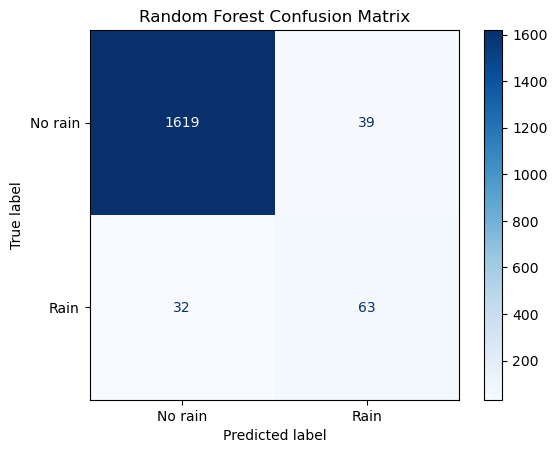

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No rain", "Rain"]) 
disp.plot(cmap=plt.cm.Blues) # Customize colormap if desired
plt.title("Random Forest Confusion Matrix")
plt.show()